In [1]:
from calibration import process_segment
import numpy as np
import os
import sys
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, balanced_accuracy_score, matthews_corrcoef, classification_report
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
import pandas as pd
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils.dataframe import dataframe_to_rows
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import re

In [2]:

segments = ["01_PB2", "02_PB1", "03_PA", "04_HA", "05_NP", "06_NA", "07_MP", "08_NS"]
all_results = {}
class_wise_summary_data = []
class_names = ['Human', 'Avian', 'Non-human Mammal']
for seg in segments:
    y_true_path = f'/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section1/{seg}/y_train.npy'
    logit_pattern = f'/home/hnguyen/Documents/PhD/Part2/Paper_02_Preparation/data/section1/{seg}/pre_2020_logits.npy' # OOF of training data, so n_fold=1
    stats_summary, class_wise_fold_metrics_orig, class_wise_fold_metrics_cal = process_segment(seg, y_true_path, logit_pattern, n_fold=1, output_dir="../../results/pre2020_calibration", save_path="../../results/pre2020_calibration")
    all_results[seg] = stats_summary
    ############### Class-wise#######################
    orig_metrics = class_wise_fold_metrics_orig[0]['orig']
    cal_metrics = class_wise_fold_metrics_cal[0]['cal']
    
    # Orig class details
    per_class_orig = orig_metrics['per_class_details']
    for cls_idx, cls_name in enumerate(class_names):
        class_wise_summary_data.append({
            'Segment': seg,
            'Calibration': 'Orig',
            'Class': cls_name,
            'ECE': round(per_class_orig['ece'][cls_idx], 4),
            'MCE': round(per_class_orig['mce'][cls_idx], 4),
            'ACE': round(per_class_orig['ace'][cls_idx], 4),
            'MCS': round(per_class_orig['mcs'][cls_idx], 4)
        })
    # Cal class details  
    per_class_cal = cal_metrics['per_class_details']
    for cls_idx, cls_name in enumerate(class_names):
        class_wise_summary_data.append({
            'Segment': seg,
            'Calibration': 'Cal',
            'Class': cls_name,
            'ECE': round(per_class_cal['ece'][cls_idx], 4),
            'MCE': round(per_class_cal['mce'][cls_idx], 4),
            'ACE': round(per_class_cal['ace'][cls_idx], 4),
            'MCS': round(per_class_cal['mcs'][cls_idx], 4)
        })
    ##################################################
df_summary_class_wise = pd.DataFrame(class_wise_summary_data)
df_summary_class_wise['Directionality'] = df_summary_class_wise['MCS'].apply(lambda x: 'BALANCED' if abs(x)<= 0.02
                                                                             else 'OVERCONF' if x > 0
                                                                             else 'UNDERCONF')
    
df_summary_class_wise.to_csv('../../results/pre2020_calibration/class_wise_cv_summary.csv', index=False)                             
df = pd.DataFrame.from_dict(all_results, orient='index')

# Define Metrics for Row 2 and Row 3
cal_metric_names = ['ECE', 'MCS', 'MCE', 'ACE']
cal_metric_keys = ['ece', 'mcs', 'mce', 'ace']

perf_metric_names = ['F1', 'BalAcc', 'MCC']
perf_metric_keys = ['f1', 'bal_acc', 'mcc']

# Combine for single loop
all_metric_keys = cal_metric_keys + perf_metric_keys

summary_data = {}
for seg in segments:
    segment_data = all_results[seg]
    summary_seg = {}
    for metric in all_metric_keys:
        orig_key = f'{metric}_orig'
        cal_key = f'{metric}_cal'
        summary_seg[orig_key] = f"{np.mean(segment_data[orig_key]):.3f} ± {np.std(segment_data[orig_key]):.3f}"
        summary_seg[cal_key] = f"{np.mean(segment_data[cal_key]):.3f} ± {np.std(segment_data[cal_key]):.3f}"
    summary_data[seg] = summary_seg

df = pd.DataFrame.from_dict(summary_data, orient='index')

def parse_mean(val):
    return float(re.split(r' ± ', str(val))[0])

means_df = df.map(parse_mean)

def highlight_max_min(col):
    is_max = col == col.max()
    is_min = col == col.min()
    styles = []
    for max_flag, min_flag in zip(is_max, is_min):
        if max_flag:
            styles.append('font-weight: bold; color: green; background-color: lightgreen')
        elif min_flag:
            styles.append('font-weight: bold; color: red; background-color: #ffcccc')
        else:
            styles.append('')
    return styles
styled_df = df.style.apply(highlight_max_min, axis=0).format(precision=3)
styled_df.to_html('../../results/pre2020_calibration/table_highlighted.html')  # Colors work
styled_df  # Jupyter display


def get_safe_text_position(x, y, existing_boxes, x_limit=(0,1), y_limit=(0,1)):
    """
    Simple collision detection to find a free spot for text.
    Tries 4 positions around the point: Top-Right, Top-Left, Bottom-Right, Bottom-Left.
    """
    offsets = [
        (0.02, 0.05),   # Top-Right (Preferred)
        (-0.15, 0.05),  # Top-Left
        (0.02, -0.15),  # Bottom-Right
        (-0.15, -0.15)  # Bottom-Left
    ]
    
    # Size approximation of the text box in data coordinates
    w, h = 0.15, 0.10 
    
    best_x, best_y = x + offsets[0][0], y + offsets[0][1]
    min_overlap = float('inf')
    
    for dx, dy in offsets:
        test_x, test_y = x + dx, y + dy
        
        # 1. Check Limits (stay inside plot)
        if not (x_limit[0] < test_x < x_limit[1] - w and y_limit[0] < test_y < y_limit[1] - h):
            continue
            
        # 2. Check Overlap with existing boxes
        overlap = 0
        for (ex, ey, ew, eh) in existing_boxes:
            # Simple rectangle intersection check
            if not (test_x + w < ex or test_x > ex + ew or test_y + h < ey or test_y > ey + eh):
                overlap += 1 # Collision detected
        
        if overlap < min_overlap:
            min_overlap = overlap
            best_x, best_y = test_x, test_y
            if overlap == 0: break # Found a perfect spot
            
    # Record this new box as taken space
    existing_boxes.append((best_x, best_y, w, h))
    return best_x, best_y


# Helper to find best corner (reused)
def get_best_corner_for_summary(existing_boxes):
    corners = [(0.95, 0.05, 'right', 'bottom'), (0.05, 0.95, 'left', 'top'), 
               (0.05, 0.05, 'left', 'bottom'), (0.5, 0.05, 'center', 'bottom')]
    best_corner = corners[0]; max_dist = -1
    for x, y, ha, va in corners:
        min_d = float('inf')
        for (ex, ey, ew, eh) in existing_boxes:
            d = np.sqrt((x-(ex+ew/2))**2 + (y-(ey+eh/2))**2)
            if d < min_d: min_d = d
        if min_d > max_dist: max_dist = min_d; best_corner = (x, y, ha, va)
    #return (0.02, 0.97, 'left', 'top')
    return best_corner

# =======================================================
# Calibration errors plot
# =======================================================
def plot_calibration_errors_2x4(all_results, save_path=None, suptitle=None):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
    legend_handles = [
        mpatches.Patch(color='salmon', label='Orig'),
        mpatches.Patch(color='royalblue', label='Calib'),
    ]
    for idx, seg in enumerate(segments):
        r = idx // 4
        c = idx % 4
        ax = axes[r, c]

        res = all_results.get(seg, {})
        if not res:
            ax.set_title(f"{seg} (No Data)")
            continue

        orig_means = [np.mean(res.get(f"{k}_orig", [0])) for k in cal_metric_keys]
        cal_means  = [np.mean(res.get(f"{k}_cal",  [0])) for k in cal_metric_keys]

        x = np.arange(len(cal_metric_names))
        width = 0.35

        ax.bar(x - width/2, orig_means, width, color='salmon',   label='Orig')
        ax.bar(x + width/2, cal_means,  width, color='royalblue', label='Calib')

        label_seg = '07_M' if seg == '07_MP' else seg
        ax.set_title(f"{label_seg}", fontsize=18, pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels(cal_metric_names, fontsize=14)
        ax.grid(True, axis='y', alpha=0.3)

        if c == 0:
            ax.set_ylabel("Error")
            ax.tick_params(axis='y', labelsize=12)
    fig.legend(
        handles=legend_handles,
        #title="Subtype",
        loc='upper center',
        bbox_to_anchor=(0.5, 1.04), # Anchored above the plots
        ncol=len(legend_handles),  # Horizontal layout
        frameon=True,
        fontsize=14
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95] if suptitle else None)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# =======================================================
# PERFORMANCE Plot
# =======================================================
def plot_performance_2x4(all_results, save_path=None, suptitle=None):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharey=True)
    legend_handles = [
        mpatches.Patch(color='salmon', label='Orig'),
        mpatches.Patch(color='royalblue', label='Calib'),
    ]
    for idx, seg in enumerate(segments):
        r = idx // 4
        c = idx % 4
        ax = axes[r, c]

        res = all_results.get(seg, {})
        if not res:
            ax.set_title(f"{seg} (No Data)")
            continue

        orig_means = [np.mean(res.get(f"{k}_orig", [0])) for k in perf_metric_keys]
        cal_means  = [np.mean(res.get(f"{k}_cal",  [0])) for k in perf_metric_keys]

        x = np.arange(len(perf_metric_names))
        width = 0.35

        ax.bar(x - width/2, orig_means, width, color='salmon',   label='Orig')
        ax.bar(x + width/2, cal_means,  width, color='royalblue', label='Calib')

        label_seg = '07_M' if seg == '07_MP' else seg
        ax.set_title(f"{label_seg}", fontsize=18, pad=12)
        ax.set_xticks(x)
        ax.set_xticklabels(perf_metric_names, fontsize=14)
        ax.grid(True, axis='y', alpha=0.3)

        if c == 0:
            ax.set_ylabel("Score", fontsize=14)
            ax.tick_params(axis='y', labelsize=12)
    fig.legend(
        handles=legend_handles,
        #title="Subtype",
        loc='upper center',
        bbox_to_anchor=(0.5, 1.04), # Anchored above the plots
        ncol=len(legend_handles),  # Horizontal layout
        frameon=True,
        fontsize=14
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95] if suptitle else None)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

# =======================================================
# Reliability Plot
# =======================================================
def plot_reliability_2x4(all_results, save_path=None, suptitle=None):
    fig, axes = plt.subplots(2, 4, figsize=(20, 10), sharex=True, sharey=True)
    legend_handles = [
        Line2D([0], [0], color='salmon', marker='o', lw=2.5, markersize=6, label='Orig'),
        Line2D([0], [0], color='royalblue', marker='o', lw=2.5, markersize=6, label='Calib')
    ]
    for idx, seg in enumerate(segments):
        r = idx // 4
        c = idx % 4
        ax = axes[r, c]

        res = all_results.get(seg, {})
        if not res:
            ax.set_title(f"{seg} (No Data)")
            continue

        stats_o = res.get('ens_stats_orig', [])
        stats_c = res.get('ens_stats_cal', [])

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.5)

        # Orig curve
        confs_o = [b['conf'] for b in stats_o if b['conf'] is not None]
        accs_o  = [b['acc']  for b in stats_o if b['acc']  is not None]
        if confs_o:
            ax.plot(confs_o, accs_o,
                    marker='o', markersize=3,
                    color='salmon', linewidth=1.8,
                    label='Orig')

        # Calib curve
        confs_c = [b['conf'] for b in stats_c if b['conf'] is not None]
        accs_c  = [b['acc']  for b in stats_c if b['acc']  is not None]
        existing_boxes = []
        for cx, cy in zip(confs_c, accs_c):
            # reserve a small box around each bin point
            existing_boxes.append((cx - 0.02, cy - 0.02, 0.04, 0.04))

        if confs_c:
            ax.plot(confs_c, accs_c,
                    marker='o', markersize=3,
                    color='royalblue', linewidth=1.8,
                    label='Calib')

            # ----- Annotate Bad Bins -----
            bins_to_annotate = [b for b in stats_c
                                if b['gap'] is not None and b['gap'] > 0.05]
            bins_to_annotate.sort(key=lambda x: x['gap'], reverse=True)

            for b in bins_to_annotate:
                prop_pct = b['prop'] * 100
                txt = f"cnt:{b['count']}\nprop:{prop_pct:.1f}%\ngap:{b['gap']:.3f}"

                txt_x, txt_y = get_safe_text_position(
                    b['conf'], b['acc'], existing_boxes,
                    x_limit=(0, 1), y_limit=(0, 1)
                )
                existing_boxes.append((txt_x, txt_y, 0.15, 0.10))

                ax.annotate(
                    txt,
                    xy=(b['conf'], b['acc']),
                    xytext=(txt_x, txt_y),
                    arrowprops=dict(arrowstyle="-|>", color='blue', lw=0.5),
                    fontsize=7, ha='left', va='bottom',
                    color='darkblue', fontweight='bold',
                    bbox=dict(boxstyle='round,pad=0.2',
                              fc='white', edgecolor='blue', alpha=0.9)
                )

            # ----- Annotate "Well-Calibrated" -----
            total_good_prop = sum(
                b['prop'] for b in stats_c
                if b['gap'] is not None and b['gap'] <= 0.05
            ) * 100

            bx, by, bha, bva = (0.02, 0.97, 'left', 'top') #get_best_corner_for_summary(existing_boxes)
            ax.text(
                bx, by,
                f"Well-Calibrated: {total_good_prop:.1f}%",
                transform=ax.transAxes,
                fontsize=9, fontweight='bold',
                color='darkgreen', ha=bha, va=bva,
                bbox=dict(boxstyle='round,pad=0.3',
                          fc='#e6ffe6', edgecolor='green', alpha=0.9)
            )

        label_seg = '07_M' if seg == '07_MP' else seg
        ax.set_title(f"{label_seg}", fontsize=14, pad=10)
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
        ax.grid(True, alpha=0.3)
        ax.tick_params(axis='y', labelsize=12)
        ax.tick_params(axis='x', labelsize=12)

        if r == 1:
            ax.set_xlabel("Confidence", fontsize=14)
        if c == 0:
            ax.set_ylabel("Accuracy", fontsize=14)
    fig.legend(
        handles=legend_handles,
        #title="Subtype",
        loc='upper center',
        bbox_to_anchor=(0.5, 1.04), # Anchored above the plots
        ncol=len(legend_handles),  # Horizontal layout
        frameon=True,
        fontsize=14
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=14, y=0.98)
    fig.tight_layout(rect=[0, 0, 1, 0.95] if suptitle else None)

    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()    


################################################################################
PROCESSING SEGMENT: 01_PB2
################################################################################

FOLD 0
Metric          | F1 Orig   | F1 Calib  | ECE Orig  | ECE Calib | MCS Orig  | MCS Calib | MCE Orig  | MCE Calib | ACE Orig  | ACE Calib
------------------------------------------------------------------------------------------------------------------------
Values          | 0.9317    | 0.9502    | 0.0782    | 0.0020    | -0.0782   | -0.0006   | 0.1712    | 0.0967    | 0.0782    | 0.0011   
------------------------------------------------------------------------------------------------------------------------
Additional      | Bal Acc: 0.9516->0.9445 | MCC: 0.9157->0.9357
------------------------------------------------------------------------------------------------------------------------

 Fold 0 - Original Bins (Top 10 Worst)
Bin             | Count  | Prop   | Conf   | Acc    | Gap    | 

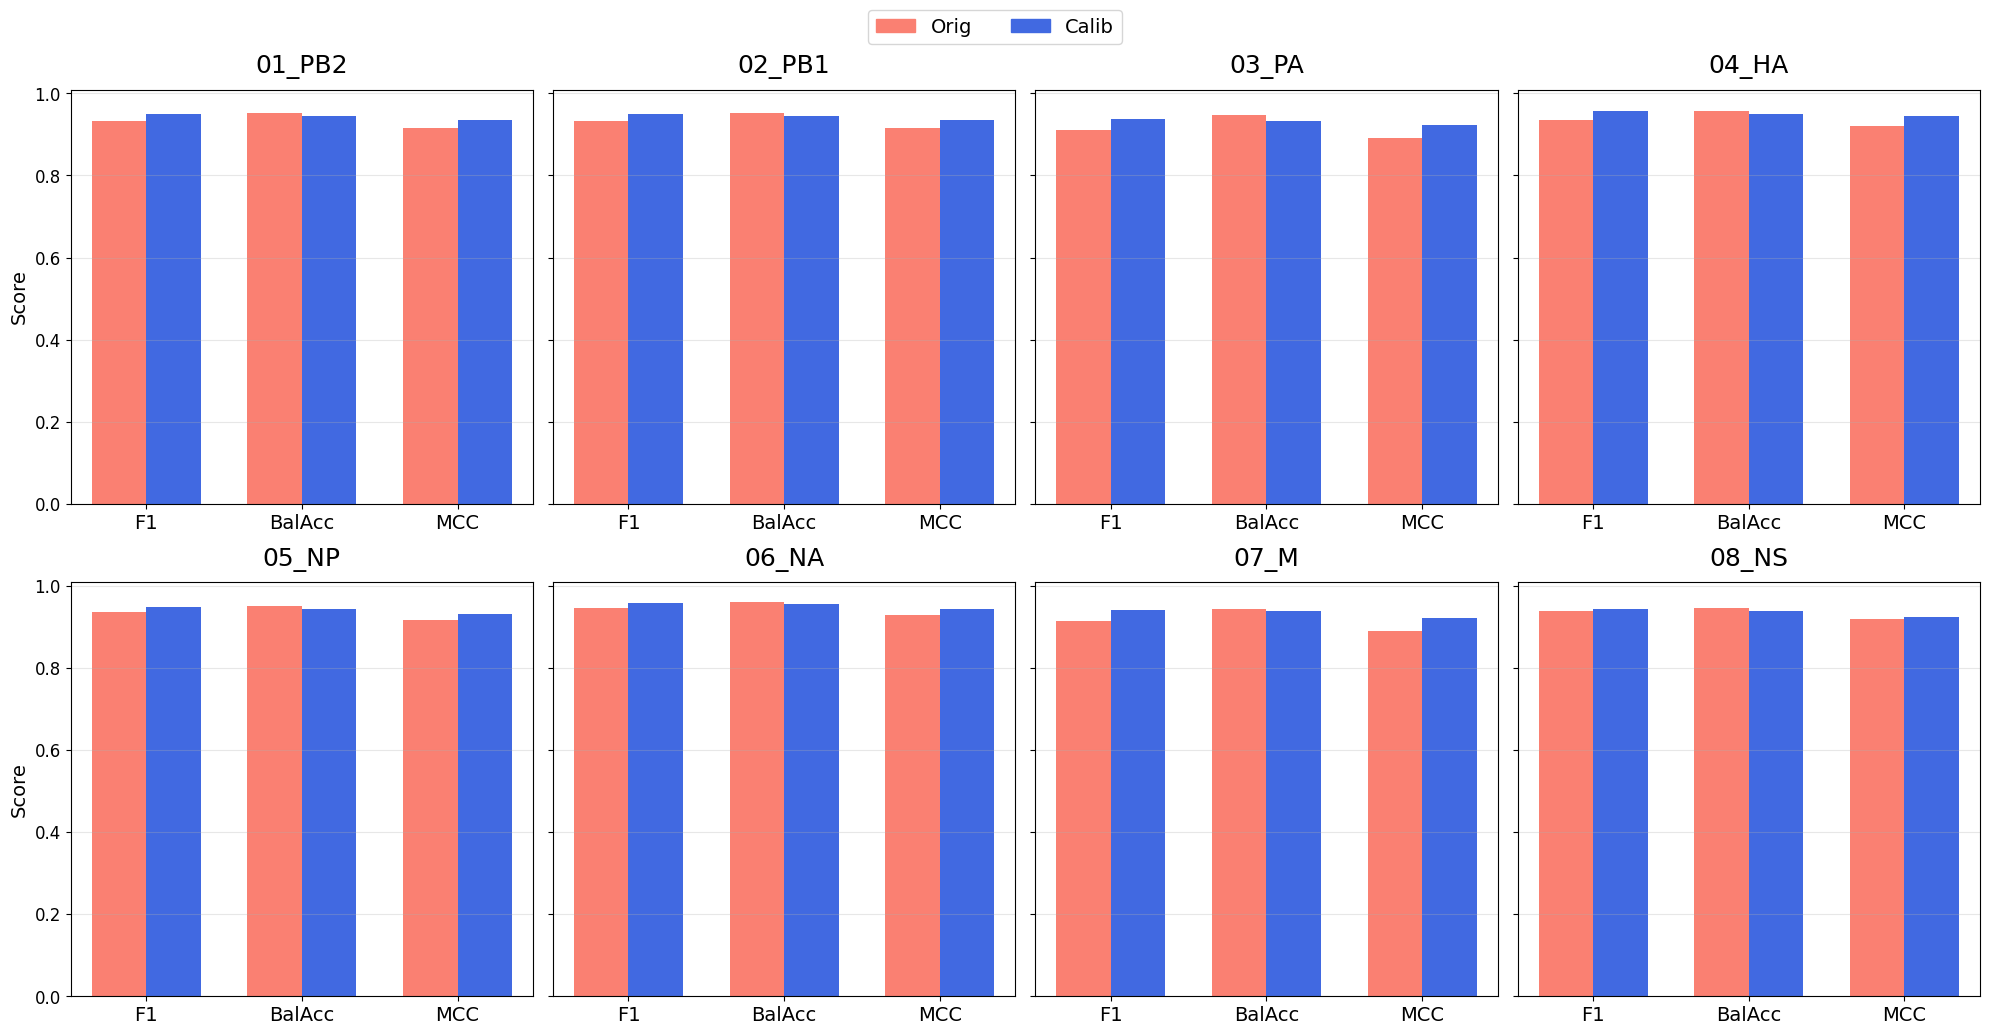

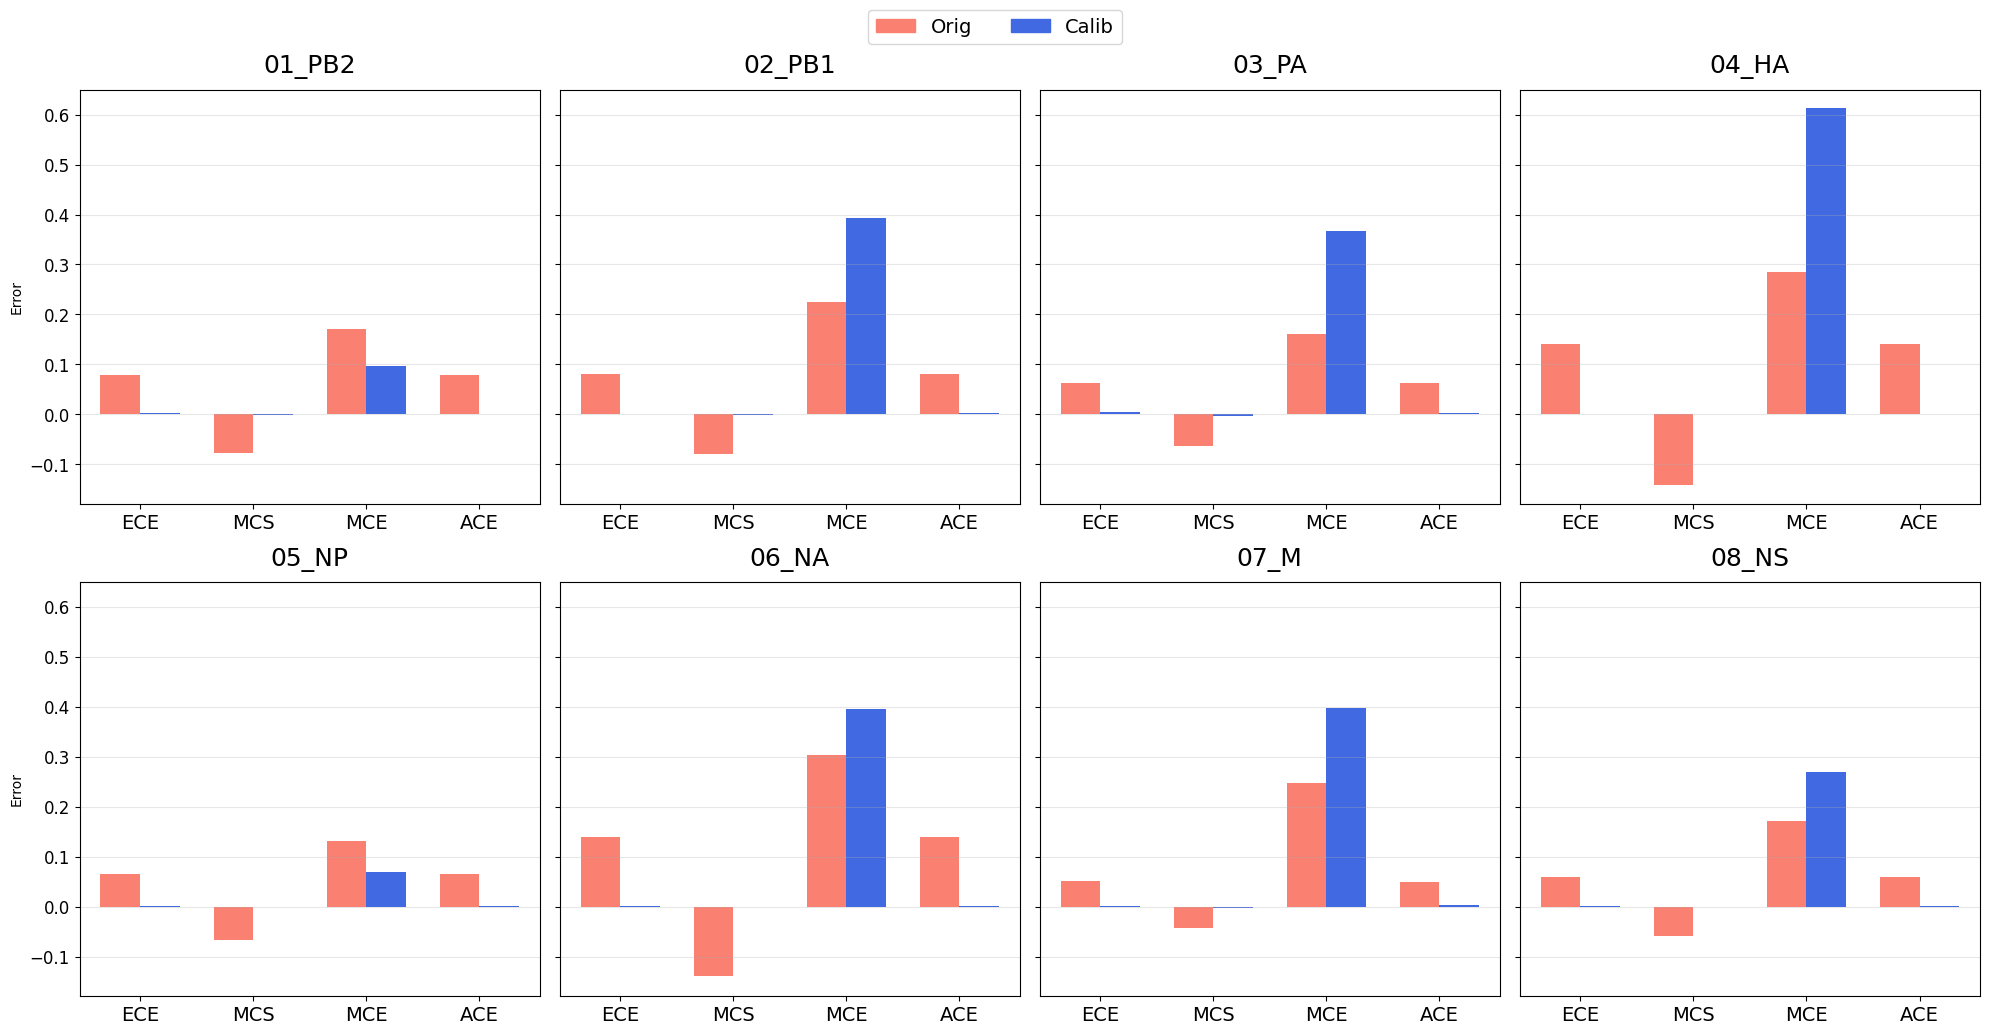

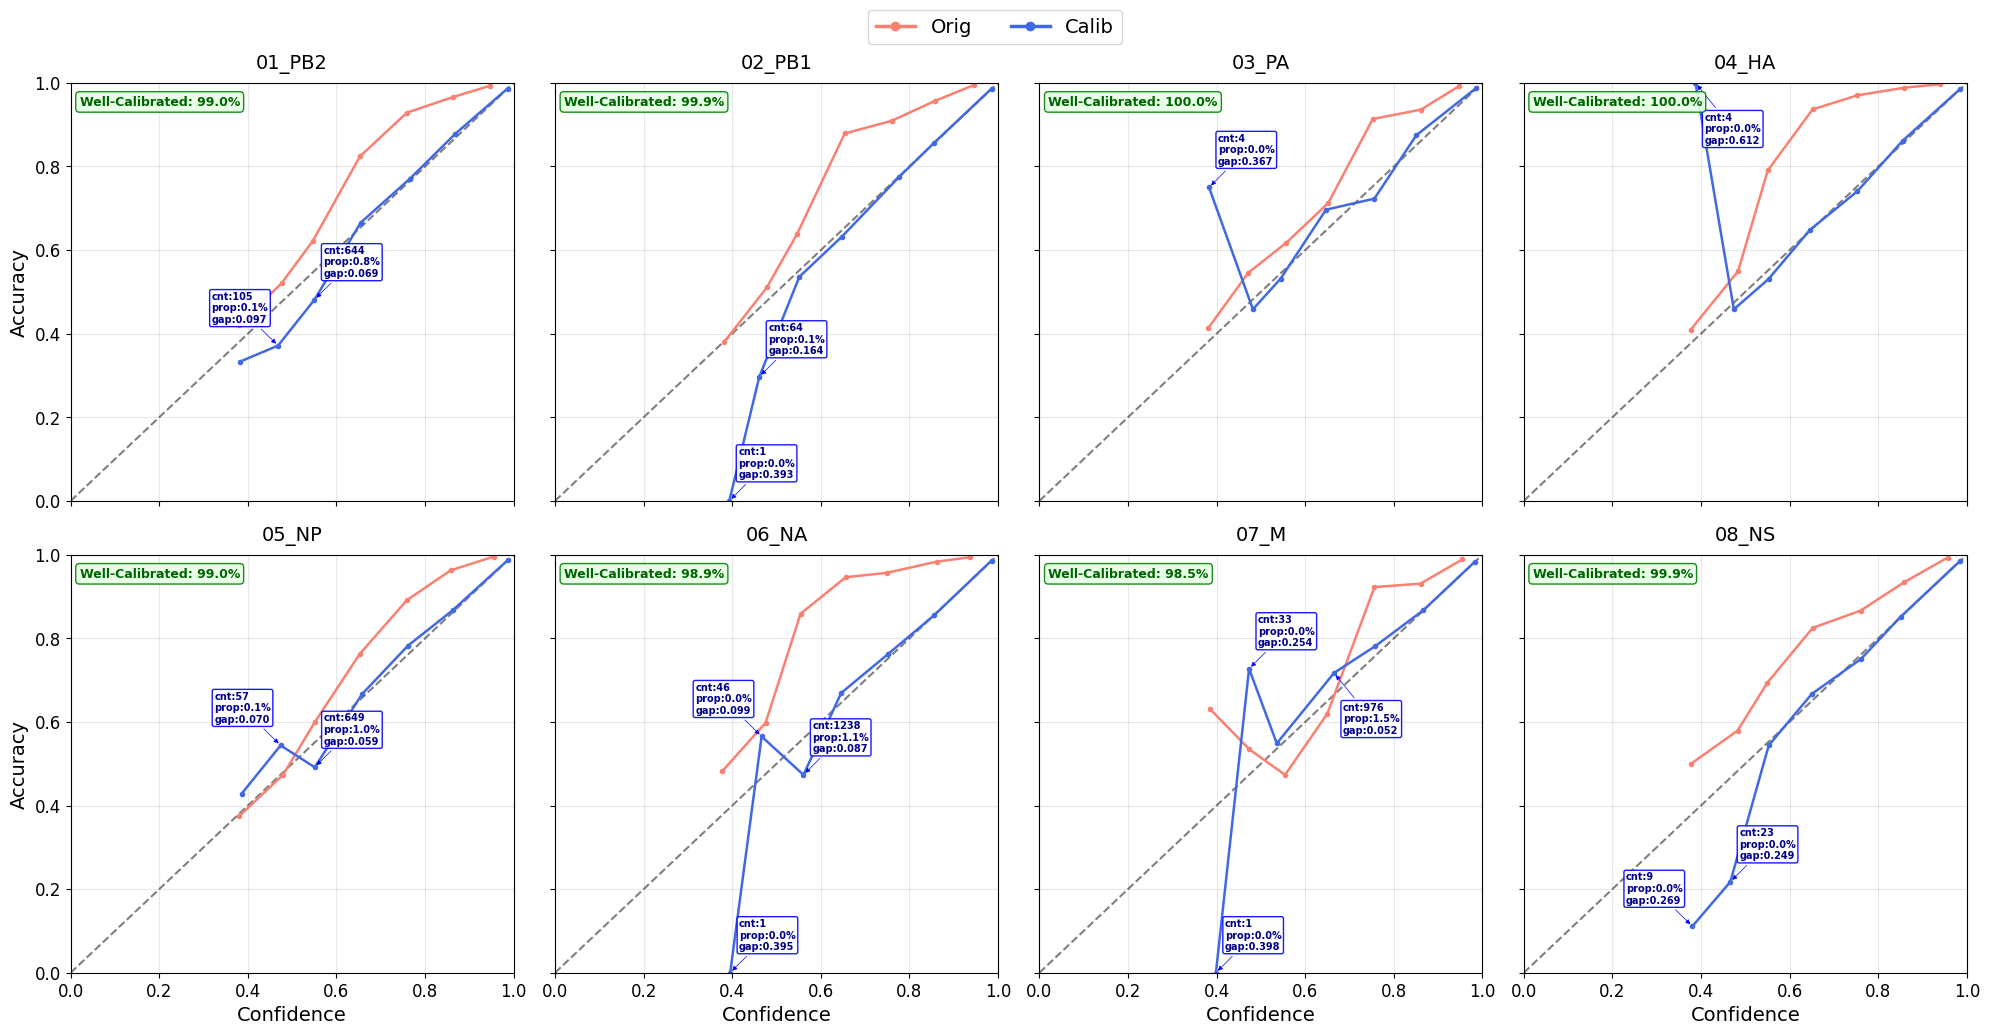

In [4]:
plot_performance_2x4(
    all_results,
    save_path="../../results/Supplementary_Figure_S2_Model_Performance.png",
)
plot_calibration_errors_2x4(
    all_results,
    save_path="../../results/Supplementary_Figure_S3_Calibration_Error.png",
)
plot_reliability_2x4(
    all_results,
    save_path="../../results/Supplementary_Figure_S4_Reliability_Diagram.png",
)
